# Derivatives and Loss Functions

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute derivatives symbolically and numerically
- Understand gradients for scalar and multivariate functions
- Link derivatives to optimization

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — you hand-coded MSE and its gradient there and watched the loss fall to 3,890; this notebook derives where that gradient formula comes from.

**Used later in:** Course 08 (AIAT 122) — Unit 1, lesson 05 "Backpropagation Detailed" — the same derivative, computed for you by `loss.backward()`.

---


---

## 📌 Real case: why deep networks would not train, and how a derivative explained it

Through the 2000s, networks deeper than a few layers routinely failed to learn — not slowly, but not at all.
In 2010 Xavier Glorot and Yoshua Bengio published *"Understanding the difficulty of training deep
feedforward neural networks"* (AISTATS), which traced the failure to the **derivative of the activation
function**. The logistic sigmoid has σ'(z) = σ(z)·(1 − σ(z)), and that quantity has a hard ceiling: its
largest possible value is **0.25**, at z = 0, and it collapses toward zero as soon as the unit saturates.
Backpropagation multiplies one such factor per layer. Ten sigmoid layers therefore scale the gradient
reaching the first layer by at most 0.25¹⁰ ≈ **10⁻⁶** — the early layers get essentially no signal, and
they stay at their initial values.

The fix that unlocked deep learning was a change of derivative, not of architecture: ReLU, whose derivative
is exactly 1 wherever the input is positive, so the product does not shrink.

**What goes wrong without this.** You would have a network that trains for days, reports a falling loss,
and has learned nothing in its first five layers — with no error message anywhere. Reading the derivative
is what turns "it doesn't work" into "it multiplies by ≤ 0.25 per layer, so of course it doesn't work."


# Derivatives and Loss Functions

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Module 01: Linear Algebra** - Understand vectors and matrices
- ✅ **Example 1: Vectors and Matrices** - Understand data representation
- ✅ **Basic calculus**: Understanding of slopes and rates of change

**If you haven't completed these**, you might struggle with:
- Understanding why derivatives matter
- Understanding gradient computation
- Using derivatives for optimization

---

## 🔗 Where This Notebook Fits

**This is the FIRST example of Module 02** - foundation for all optimization!

**Why this example FIRST?**
- **Before** you can compute gradients, you need to understand derivatives
- **Before** you can optimize models, you need to understand loss functions
- **Before** you can train neural networks, you need gradient descent

**Builds on**: Module 01 (vectors and matrices)

**Leads to**: 
- 📓 Example 2: Gradients (needs derivative understanding)
- 📓 Example 3: Gradient Descent (needs gradient understanding)
- 📓 Module 03: Optimization (uses gradients from this module)

---

## The Story: Understanding Before Using

Imagine you're hiking and want to find the lowest point. **Before** you can find it, you need to know which direction is downhill. **After** understanding derivatives, you know the direction of steepest descent - exactly what gradient descent uses!

Same with machine learning: **Before** training models, we need to know which direction to adjust parameters. **After** understanding derivatives, we can minimize loss functions and train models!

---

## Why This Concept Matters

### Why Derivatives Matter in ML

**WHY** are derivatives essential for machine learning?

1. **Finding Minimum Loss**:
   - **WHY**: ML models are trained by minimizing loss functions
   - **HOW**: Derivatives tell us which direction decreases loss
   - **AFTER**: Enables model training

2. **Optimization Direction**:
   - **WHY**: Need to know which way to adjust parameters
   - **HOW**: Derivative = slope = direction of change
   - **AFTER**: Can optimize efficiently

3. **Neural Network Training**:
   - **WHY**: Backpropagation relies entirely on derivatives
   - **HOW**: Chain rule computes derivatives through layers
   - **AFTER**: Enables deep learning

**Common Student Questions:**
- **Q: What is a derivative?**
  - Answer: Derivative = rate of change (slope) of a function
  - Tells us: How fast function changes at a point
  - Example: Position → derivative = velocity (rate of change of position)
  - In ML: Loss function → derivative = direction to minimize loss
- **Q: Why do we need derivatives in ML?**
  - Answer: ML trains models by minimizing loss → need to know which direction decreases loss
  - Derivative = slope → positive slope = increasing (move left), negative slope = decreasing (move right)
  - Gradient descent uses derivatives to find minimum → train models
  - Without derivatives: Can't optimize → can't train models
- **Q: What's the difference between derivative and gradient?**
  - Answer: Derivative = for 1D functions (one variable), Gradient = for multi-dimensional functions (many variables)
  - Derivative: f(x) → f'(x) = one number (slope)
  - Gradient: f(x,y,z) → ∇f = [∂f/∂x, ∂f/∂y, ∂f/∂z] = vector (direction of steepest increase)
  - In ML: Usually have many parameters → use gradients (not just derivatives)
- **Q: How do derivatives help find minimum?**
  - Answer: Derivative = 0 at minimum/maximum (flat point)
  - Positive derivative → function increasing → move left (decrease x)
  - Negative derivative → function decreasing → move right (increase x)
  - Follow negative derivative → eventually reach minimum
  - This is exactly what gradient descent does!
- **Q: What is the chain rule?**
  - Answer: Chain rule = way to compute derivative of composite functions
  - Formula: (f(g(x)))' = f'(g(x)) * g'(x)
  - Why important: Neural networks = composition of many functions
  - Backpropagation uses chain rule to compute gradients through layers
  - Without chain rule: Can't train deep neural networks!

## Learning Objectives
1. Understand what derivatives represent
2. Compute derivatives of loss functions
3. See how derivatives guide optimization
4. Visualize loss functions and derivatives
5. Understand the connection to gradient descent
6. Apply to real ML scenarios

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have loss functions but don't know how to minimize them.

**AFTER**: We'll understand how derivatives guide us to minimize loss!

**Why this matters**: Derivatives are the foundation of all ML optimization!

## Step 2: Understanding Derivatives

**BEFORE**: We have a loss function but don't know how to minimize it.

**AFTER**: We'll understand how derivatives tell us the direction to minimize loss!

**Why derivatives?** They tell us the slope - positive slope means increasing (move left), negative slope means decreasing (move right)!

In [2]:
# Example 1: Understanding Derivatives
# WHY: Derivatives tell us which direction to minimize loss
# HOW: Derivative = rate of change = slope

def loss_function(x):
    """A simple loss function: f(x) = x² + 3x + 2"""
    return x**2 + 3*x + 2

def loss_derivative(x):
    """Derivative: f'(x) = 2x + 3"""
    return 2*x + 3

# Evaluate at different points
x_values = [0, 1, 2, 3]
print("Example 1: Understanding Derivatives")
print("=" * 60)
for x in x_values:
    loss = loss_function(x)
    deriv = loss_derivative(x)
    direction = "decreasing (move right)" if deriv < 0 else "increasing (move left)"
    print(f"At x = {x}:")
    print(f"  - Loss: {loss:.2f}")
    print(f"  - Derivative: {deriv:.2f}")
    print(f"  - Function is {direction}")
    print(f"  - 💡 WHY: Derivative tells us direction to minimize!")
    print(f"  - 💡 HOW: Negative derivative → move right, Positive → move left")
    print()

Example 1: Understanding Derivatives
At x = 0:
  - Loss: 2.00
  - Derivative: 3.00
  - Function is increasing (move left)
  - 💡 WHY: Derivative tells us direction to minimize!
  - 💡 HOW: Negative derivative → move right, Positive → move left

At x = 1:
  - Loss: 6.00
  - Derivative: 5.00
  - Function is increasing (move left)
  - 💡 WHY: Derivative tells us direction to minimize!
  - 💡 HOW: Negative derivative → move right, Positive → move left

At x = 2:
  - Loss: 12.00
  - Derivative: 7.00
  - Function is increasing (move left)
  - 💡 WHY: Derivative tells us direction to minimize!
  - 💡 HOW: Negative derivative → move right, Positive → move left

At x = 3:
  - Loss: 20.00
  - Derivative: 9.00
  - Function is increasing (move left)
  - 💡 WHY: Derivative tells us direction to minimize!
  - 💡 HOW: Negative derivative → move right, Positive → move left



## Step 3: Derivatives and Loss Minimization

**BEFORE**: We understand derivatives but don't see how they minimize loss.

**AFTER**: We'll see how derivatives guide us to the minimum of loss functions!

**Why this matters?** This is exactly how ML models learn - by following derivatives to minimize loss!

In [3]:
# Example 2: Using Derivatives to Find Minimum
# WHY: We want to find x that minimizes loss
# HOW: Set derivative to zero (slope = 0 at minimum)

# Find minimum analytically
# f'(x) = 2x + 3 = 0
# x = -3/2 = -1.5

optimal_x = -1.5
optimal_loss = loss_function(optimal_x)

print("Example 2: Finding the Minimum")
print("=" * 60)
print(f"Optimal x (where derivative = 0): {optimal_x}")
print(f"Minimum loss: {optimal_loss:.2f}")
print(f"\n💡 WHY: At minimum, derivative = 0 (no slope)")
print(f"💡 HOW: Solve f'(x) = 0 to find optimal point")
print(f"💡 AFTER: This is the goal of optimization!")

Example 2: Finding the Minimum
Optimal x (where derivative = 0): -1.5
Minimum loss: -0.25

💡 WHY: At minimum, derivative = 0 (no slope)
💡 HOW: Solve f'(x) = 0 to find optimal point
💡 AFTER: This is the goal of optimization!


### 🧪 How good is a *numerical* derivative?

Baseline: the exact derivative f'(x) = 2x + 3 at x = 2. Change one thing: replace it with a finite
difference (f(x+h) − f(x)) / h. Measure: the error, as h shrinks over twelve orders of magnitude.
The result is the reason every framework differentiates symbolically rather than numerically.

In [4]:
# Comparative experiment: exact derivative vs finite difference, as the step size shrinks.

x0 = 2.0
exact = loss_derivative(x0)
print(f"Exact derivative of f(x) = x^2 + 3x + 2 at x = {x0}:  f'({x0}) = {exact}")
print()
print(f"{'h':>10} {'finite difference':>22} {'absolute error':>18}")
print("-" * 52)

best_h, best_err = None, float("inf")
for k in range(1, 15):
    h = 10.0 ** -k
    approx = (loss_function(x0 + h) - loss_function(x0)) / h    # forward difference
    err = abs(approx - exact)
    if err < best_err:
        best_h, best_err = h, err
    print(f"{h:10.0e} {approx:22.12f} {err:18.2e}")

print()
print(f"Smallest error at h = {best_h:.0e}  (error {best_err:.2e})")
print()
print("Conclusion the numbers support: the error does NOT keep falling as h shrinks. Two errors")
print("fight each other. Making h smaller reduces the TRUNCATION error (the formula's own bias),")
print("but f(x+h) and f(x) become nearly equal, so subtracting them cancels significant digits and")
print("ROUND-OFF takes over. The U-shape is why frameworks compute gradients analytically")
print("(automatic differentiation, notebook 04) and use finite differences only as a spot-CHECK,")
print("at a middling h - never as the gradient itself.")

Exact derivative of f(x) = x^2 + 3x + 2 at x = 2.0:  f'(2.0) = 7.0

         h      finite difference     absolute error
----------------------------------------------------
     1e-01         7.100000000000           1.00e-01
     1e-02         7.010000000000           1.00e-02
     1e-03         7.000999999999           1.00e-03
     1e-04         7.000100000027           1.00e-04
     1e-05         7.000010000091           1.00e-05
     1e-06         7.000001001956           1.00e-06
     1e-07         7.000000081803           8.18e-08
     1e-08         6.999999868640           1.31e-07
     1e-09         7.000000579183           5.79e-07
     1e-10         7.000000579183           5.79e-07
     1e-11         6.999911761341           8.82e-05
     1e-12         7.000622304076           6.22e-04
     1e-13         6.998845947237           1.15e-03
     1e-14         7.105427357601           1.05e-01

Smallest error at h = 1e-07  (error 8.18e-08)

Conclusion the numbers support: the 

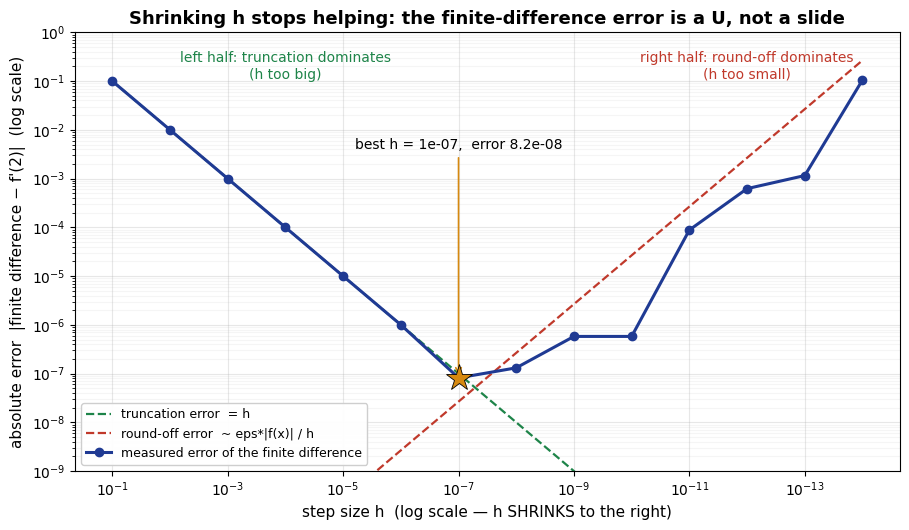

Measured minimum error 8.18e-08 at h = 1e-07.
The two dashed lines cross near h = 5.2e-08 — which is where theory says the best h sits.


In [5]:
# The U-shape the table above describes, drawn. WHY plot it: the numbers show an error
# that falls and then climbs again, and "falls then climbs" is a shape, not a column.
# WHAT is on the axes: every h from the table (log scale, SHRINKING to the right, so the
# picture reads in the same order as the printed rows) against the absolute error.

hs, errs = [], []
for k in range(1, 15):
    h = 10.0 ** -k
    hs.append(h)
    errs.append(abs((loss_function(x0 + h) - loss_function(x0)) / h - exact))
hs, errs = np.array(hs), np.array(errs)

# The two errors that fight, each predicted from theory rather than measured:
#   truncation: for f(x) = x^2 + 3x + 2 the forward difference is EXACTLY f'(x) + h,
#               so the formula's own bias is h itself.
#   round-off:  f(x+h) and f(x) agree to ~16 digits, so subtracting them loses about
#               eps*|f(x)| of accuracy, and dividing by a tiny h magnifies what is left.
eps = np.finfo(float).eps
truncation = hs
roundoff = eps * abs(loss_function(x0)) / hs

fig, ax = plt.subplots(figsize=(9.2, 5.4))
ax.loglog(hs, truncation, ls="--", lw=1.6, color="#1e8449",
          label="truncation error  = h")
ax.loglog(hs, roundoff, ls="--", lw=1.6, color="#c0392b",
          label="round-off error  ~ eps*|f(x)| / h")
ax.loglog(hs, errs, "o-", color="#1f3a93", lw=2.2, ms=6,
          label="measured error of the finite difference")

i_best = int(np.argmin(errs))
ax.plot([hs[i_best]], [errs[i_best]], "*", color="#d68910", ms=20, zorder=6,
        markeredgecolor="k", markeredgewidth=0.6)
ax.annotate(f"best h = {hs[i_best]:.0e},  error {errs[i_best]:.1e}",
            xy=(hs[i_best], errs[i_best]), xytext=(hs[i_best], 4e-3),
            fontsize=10, ha="center",
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#d68910"))

ax.set_xscale("log")
ax.invert_xaxis()          # h shrinks left -> right, same order as the printed table
ax.set_xlabel("step size h  (log scale — h SHRINKS to the right)", fontsize=11)
ax.set_ylabel("absolute error  |finite difference − f'(2)|  (log scale)", fontsize=11)
ax.set_title("Shrinking h stops helping: the finite-difference error is a U, not a slide",
             fontsize=13, fontweight="bold")
ax.set_ylim(1e-9, 1e0)
ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.12)

# Name the two halves of the U in the empty space above the curve.
ax.text(1e-4, 2.0e-1, "left half: truncation dominates\n(h too big)", fontsize=10,
        color="#1e8449", ha="center", va="center")
ax.text(1e-12, 2.0e-1, "right half: round-off dominates\n(h too small)", fontsize=10,
        color="#c0392b", ha="center", va="center")
plt.tight_layout()
plt.show()

print(f"Measured minimum error {errs[i_best]:.2e} at h = {hs[i_best]:.0e}.")
print(f"The two dashed lines cross near h = {np.sqrt(eps * abs(loss_function(x0))):.1e} — "
      f"which is where theory says the best h sits.")


**Read the figure.** The x-axis is the step size h on a log scale, **shrinking as you move right**, so
the picture reads in the same order as the table's rows. The y-axis is the absolute error of the finite
difference against the exact `f'(2) = 7`.

- The **blue measured curve is a U**, not a slide. It falls while h shrinks from 1e-1 to about 1e-7, then
  climbs back to roughly where it started by h = 1e-14 — the two ends of the blue curve sit at the same
  height. Shrinking the step past the bottom makes the answer **worse**.
- The **green dashed line falling to the right** is truncation error: the formula's own bias, which for
  this parabola is exactly h. On the left half the blue curve lies **on top of** it.
- The **red dashed line rising to the right** is round-off: `f(x+h)` and `f(x)` agree to about sixteen
  digits, so subtracting them cancels significant figures, and dividing by a tiny h magnifies what is
  left. On the right half the blue curve climbs **parallel to** this line, a little below it — round-off
  is an estimate of how many digits are lost, not an exact count, so the measured points scatter under
  the trend rather than sitting on it.
- The **orange star marks the bottom of the U**, at h = 1e-7, close to where the two dashed lines cross.
  That is the best h float64 can buy, and it still leaves about 1e-7 of error — while automatic
  differentiation (notebook 04) returns exactly 7.0.

That is why a finite difference is a spot-check, not a gradient.

---

## 📊 Visualization

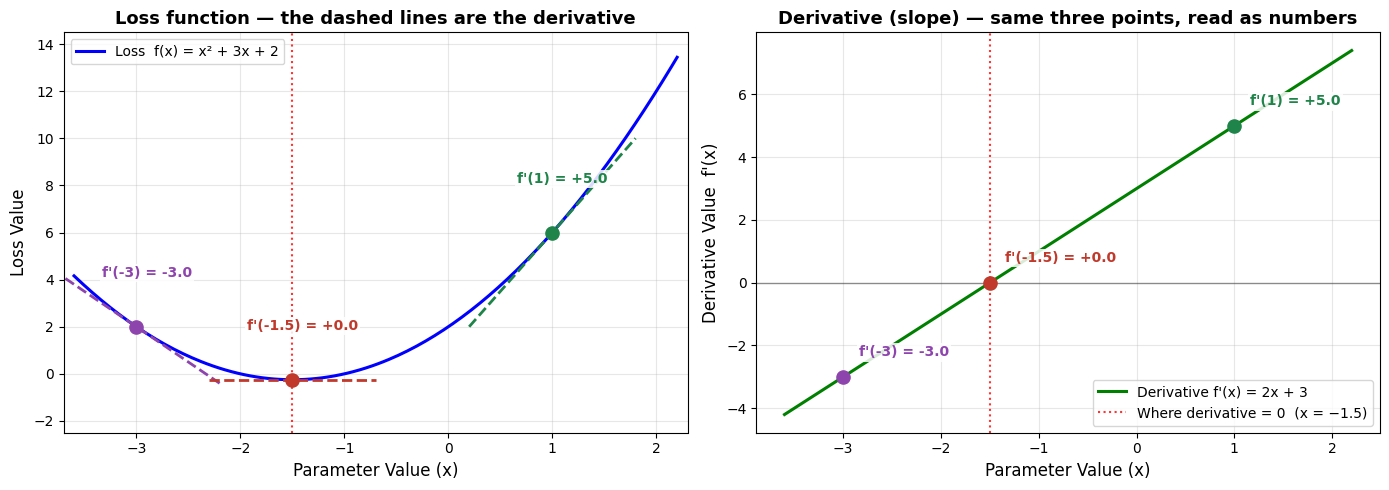


📊 Visualization:
  x =  -3.0:  slope -3.0  ->  to reduce the loss, move left
  x =  -1.5:  slope +0.0  ->  to reduce the loss, already at the minimum
  x =   1.0:  slope +5.0  ->  to reduce the loss, move right
  The three coloured dots on the right panel are the slopes of the three
  dashed lines on the left panel — the same three numbers, drawn two ways.


In [6]:
# Visualize loss function and derivative
# WHY tangent lines: the right panel plots f'(x) as a curve, but a student can read that
# curve and still not know what the number MEANS. A tangent line makes the number visible —
# the derivative at a point IS the slope of the straight line that grazes the curve there.
x_range = np.linspace(-3.6, 2.2, 200)
loss_values = loss_function(x_range)
deriv_values = loss_derivative(x_range)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---- Plot 1: the loss function, with tangent lines drawn at three sample points
ax1.plot(x_range, loss_values, 'b-', linewidth=2.2, label='Loss  f(x) = x² + 3x + 2')

# Three points chosen to show a negative slope, a zero slope, and a positive slope.
samples = [(-3.0, "#8e44ad"), (-1.5, "#c0392b"), (1.0, "#1e8449")]
for x0_s, colour in samples:
    m = loss_derivative(x0_s)                      # the derivative = the slope we draw
    xt = np.linspace(x0_s - 0.8, x0_s + 0.8, 2)
    ax1.plot(xt, loss_function(x0_s) + m * (xt - x0_s), '--', color=colour, linewidth=2)
    ax1.scatter([x0_s], [loss_function(x0_s)], color=colour, s=90, zorder=5)
    ax1.annotate(f"f'({x0_s:g}) = {m:+.1f}", xy=(x0_s, loss_function(x0_s)),
                 xytext=(x0_s + 0.10, loss_function(x0_s) + 2.1),
                 fontsize=10, color=colour, fontweight='bold', ha='center',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.5))

ax1.axvline(x=-1.5, color='r', linestyle=':', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('Parameter Value (x)', fontsize=12)
ax1.set_ylabel('Loss Value', fontsize=12)
ax1.set_title('Loss function — the dashed lines are the derivative',
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.set_xlim(-3.7, 2.3)
ax1.set_ylim(-2.5, 14.5)
ax1.grid(True, alpha=0.3)

# ---- Plot 2: the same three slopes, now read off the derivative curve
ax2.plot(x_range, deriv_values, 'g-', linewidth=2.2, label="Derivative f'(x) = 2x + 3")
ax2.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.4)
ax2.axvline(x=-1.5, color='r', linestyle=':', linewidth=1.5, alpha=0.8,
            label='Where derivative = 0  (x = −1.5)')
for x0_s, colour in samples:
    m = loss_derivative(x0_s)
    ax2.scatter([x0_s], [m], color=colour, s=90, zorder=5)
    ax2.annotate(f"f'({x0_s:g}) = {m:+.1f}", xy=(x0_s, m),
                 xytext=(x0_s + 0.16, m + 0.65), ha='left',
                 fontsize=10, color=colour, fontweight='bold',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.5))
ax2.set_xlabel('Parameter Value (x)', fontsize=12)
ax2.set_ylabel("Derivative Value  f'(x)", fontsize=12)
ax2.set_title('Derivative (slope) — same three points, read as numbers',
              fontsize=13, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Visualization:")
for x0_s, _ in samples:
    m = loss_derivative(x0_s)
    move = "move right" if m > 0 else ("move left" if m < 0 else "already at the minimum")
    print(f"  x = {x0_s:>5.1f}:  slope {m:+.1f}  ->  to reduce the loss, {move}")
print("  The three coloured dots on the right panel are the slopes of the three")
print("  dashed lines on the left panel — the same three numbers, drawn two ways.")


**Read the figure.** Both panels show the same function over the same x-range, so the two can be read
across.

- On the **left**, three dashed straight lines graze the blue parabola at x = −3, x = −1.5 and x = 1.
  Each one's steepness *is* the derivative there: the purple line at x = −3 tilts **down** (f' = −3), the
  red line at x = −1.5 is **flat** (f' = 0), the green line at x = 1 tilts **up** (f' = +5).
- On the **right**, those same three numbers are three coloured dots on the straight line f'(x) = 2x + 3.
  The red dot sits exactly where that line crosses zero.
- The red dotted vertical at **x = −1.5** lines up in both panels: the bottom of the parabola on the left,
  the zero-crossing of the derivative on the right. That alignment is the whole method — *find where the
  slope is zero and you have found the minimum.*

Note what the picture does **not** prove: a flat tangent also appears at a maximum, and at an inflection.
The "Where this breaks" section below says what to do about that.


---

## ⚠️ Where this breaks

- **Setting f'(x) = 0 finds a stationary point, not a minimum.** This notebook solved 2x + 3 = 0 and got
  a minimum only because the parabola opens upward. For a general function, a zero derivative could be a
  maximum or an inflection, and you need the second derivative to tell them apart. In many dimensions the
  problem is worse: in a high-dimensional loss surface, points with zero gradient are overwhelmingly
  **saddle points**, not minima, and a first-order method can sit near one for a long time.
- **The derivative has to exist.** ReLU has no derivative at 0; so does |x|; so does any decision rule with
  a threshold in it. Frameworks quietly pick a value (PyTorch returns 0 for ReLU at exactly 0) and carry
  on. That is a convention, not mathematics, and it is worth knowing that your gradient at that point is a
  choice someone made.
- **The numerical derivative is a check, not a tool.** The experiment above shows why: the error bottoms out
  and then gets worse. Use finite differences to verify a hand-written gradient at one point, at a moderate
  h, and never inside a training loop.


---

## 💬 Discuss

1. The sigmoid's derivative is capped at 0.25 — a fact available to anyone who could differentiate, years
   before deep networks worked. Why do you think it took until 2010 for someone to publish the diagnosis?
   What does that suggest about the value of being able to read the mathematics of a tool you use?
2. The finite-difference table shows the error getting *worse* below a certain h. A colleague proposes
   "just use h = 1e-15 to be safe." Explain to them, using the printed numbers, why that is the worst
   choice on the table.
3. Frameworks return a derivative of 0 for ReLU at exactly zero, though none exists. Is that dishonest,
   pragmatic, or dangerous? Argue one side, then say what evidence would change your mind.


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding derivatives:

1. **Model Training**: Can minimize loss functions
2. **Optimization**: Can find optimal parameters
3. **Neural Networks**: Ready to understand backpropagation
4. **Next Steps**: Learn gradients (Example 2) and gradient descent (Example 3)

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand how to minimize loss functions.

**AFTER this notebook**: We can:
- ✅ Understand WHY derivatives matter for ML
- ✅ Compute HOW derivatives work
- ✅ See what happens AFTER (optimization direction)

**Next Steps**: 
- 📓 Example 2: Gradients (extend to multiple variables)
- 📓 Example 3: Gradient Descent (use derivatives for optimization)

---

## ✅ Example Complete!

## 📚 References

1. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 5: Vector Calculus. Cambridge University Press. <https://mml-book.github.io/>
2. Baydin, A. G., Pearlmutter, B. A., Radul, A. A., & Siskind, J. M. (2018). *Automatic Differentiation in Machine Learning: A Survey*. Journal of Machine Learning Research, 18(153). <https://arxiv.org/abs/1502.05767>
3. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 4: Numerical Computation. MIT Press. <https://www.deeplearningbook.org/>
4. Blondel, M., & Roulet, V. (2024). *The Elements of Differentiable Programming*. arXiv. <https://arxiv.org/abs/2403.14606> — modern reference for the derivatives and differentiation rules this notebook computes by hand.
